<a href="https://colab.research.google.com/github/mennatallahhesham/scRNA-cell-type-classification/blob/main/Menna's_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction
Welcome to the ML-Bio graduation Project.  
Our task is really interesting and one of the main stream work done in single cell projects.  
  
Single cell RNA-sequencing, is all about analysing the gene expression as you would know but on single cell level. This means that a certain sample from certain donor can provied us with thousands of cells, and for each we meassure the gene expression. To understand more about single cell RNA-sequencing you can read [here](https://genomemedicine.biomedcentral.com/articles/10.1186/s13073-017-0467-4). Never the less we dont need to have deep knowledge to continue in our task. I have made a picture to summarize the analysis for you:    

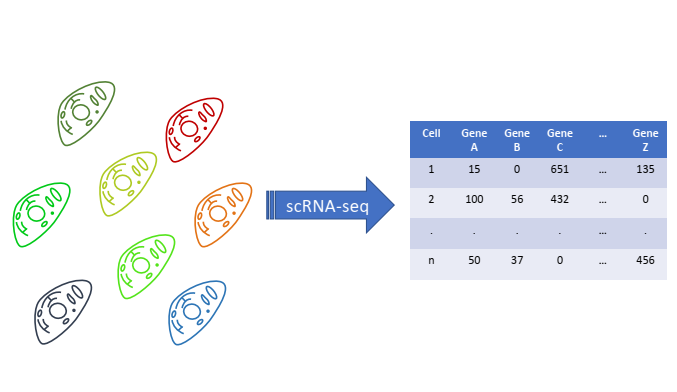  

Our data is coming from a paper puplished in 2021 by Malte D. et. al. called "A sandbox for prediction and integration of DNA, RNA, and proteins in single cells".  You can find the raw data under [GEO](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE194122).  
  
Single cell data annotation is an essential step in single cell data analytics. at that step, we need for each cell (record) in the matrix to assign it to a cell type. This is step is essential for the analysis in order to complete downstream analysis. Classically cell type annotation is done manually by comparing the gene expression of cells againist a refrence **Which can take months**. Many papers have tackled how to make automatic annotation  using machine learning as in this [paper](https://www.nature.com/articles/s41467-022-33045-x) puplished in nature.  

Our tasks in this project is to use the expression matrix of the single cell data to predict the cell_type.

## Instructions
- You need to work in team of maximum 4.  
- You are allowed to have discussion about the problems, but coding and submission should be individual.
- It is always fine to search online for any function or package or debugging that can help you.
- We may have an office hours upon your request, it would be great if you have already started working so that the discussions be more helpful.
- Data is provided as train and test:      
 **BMMC_exp_(train/test).csv.gz** is the expression matrix, where each row is a cell and each column is the gene. Hence, each value is the gene expression for certain gene in certain cell.   
 **BMMC_cell_metadata_(train/test).csv.gz** is information about the cells such as:  
 - cell_type: represent our label, which is the type of the cell, either (Naive CD20+ B, CD4+ T activated or NK).
 - batch: is the sample (s1, s2, s3 or s4) and the donor who gave it (1 - 10). Note that from same donor we can obtain diffrent samples.
 - DonorAge: is the Age of the donor
 - DonorBMI: Body Mass Index of the donor
 - DonorBloodType: Blood type of the donor
 - Ethinicity: ethinicity of the donor
 - DonorGender: Gender of the donor
 - DonorSmoker: is the donor smoker  

 You need to make all your analysis on the training data and at the end **report your accuracy metrics on the test data.**  

## Task 1: Preprocessing, Cleaning

Load and analyze the data and decide on appropriate preprocessing steps. Please explain why you choose these specific preprocessing steps.
tip: you can import your data directly with its index without decompressing them as below:
```{python}
exp_train = pd.read_csv("BMMC_exp_train.csv.gz", index_col = 0)
```

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import urllib, io, gzip, sys
from collections import defaultdict
np.random.seed(0)

In [ ]:
metadata_test = pd.read_csv('/content/gdrive/MyDrive/ML lab/Copy of BMMC_cell_metadata_test.csv.gz', index_col = 0) # you will need to change the path
metadata_train = pd.read_csv('/content/gdrive/MyDrive/ML lab/Copy of BMMC_cell_metadata_train.csv.gz', index_col = 0)  # you will need to change the path
print('Metadatas have been loaded...')
print(metadata_test.info())
print(metadata_train.info())

Metadatas have been loaded...
<class 'pandas.core.frame.DataFrame'>
Index: 3168 entries, GCCTTACTCGTTACAA-1-s1d1 to AGCATCCCACAGAACG-12-s4d9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cell_type       3168 non-null   object 
 1   batch           3168 non-null   object 
 2   DonorAge        3168 non-null   int64  
 3   DonorBMI        3168 non-null   float64
 4   DonorBloodType  3168 non-null   object 
 5   Ethnicity       3168 non-null   object 
 6   DonorGender     3168 non-null   object 
 7   DonorSmoker     3168 non-null   object 
dtypes: float64(1), int64(1), object(6)
memory usage: 222.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 14339 entries, TAGTTGTCACCCTCAC-1-s1d1 to CACTTAAAGTCTGGGC-12-s4d9
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   cell_type       14339 non-null  object 
 1   batch           14339 no

In [ ]:
test_data = pd.read_csv('/content/gdrive/MyDrive/ML lab/Copy of BMMC_exp_test.csv.gz', index_col = 0)  # you will need to change the path
train_data = pd.read_csv('/content/gdrive/MyDrive/ML lab/Copy of BMMC_exp_train.csv.gz', index_col = 0)

print('Datasets have been loaded...')
print(test_data.info())
print(train_data.info())

Datasets have been loaded...
<class 'pandas.core.frame.DataFrame'>
Index: 3168 entries, GCCTTACTCGTTACAA-1-s1d1 to AGCATCCCACAGAACG-12-s4d9
Columns: 2533 entries, C1orf159 to AL592183.1
dtypes: float64(2533)
memory usage: 61.2+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 14339 entries, TAGTTGTCACCCTCAC-1-s1d1 to CACTTAAAGTCTGGGC-12-s4d9
Columns: 2533 entries, C1orf159 to AL592183.1
dtypes: float64(2533)
memory usage: 277.2+ MB
None


In [ ]:
test_data

,C1orf159,SLC35E2B,SLC2A5,GPR157,KIF1B,AL109811.2,DRAXIN,CLCN6,AL021155.5,KAZN,...,TMLHE,MT-ND1,MT-ND2,MT-ATP8,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,AL592183.1
GCCTTACTCGTTACAA-1-s1d1,0.0,1.732819,0.0,1.202458,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,2.077548,1.202458,0.000000,0.000000,0.000000,1.202458,1.732819,0.000000,1.732819
AGCAATACAATATGGA-1-s1d1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,3.040721,2.394267,0.000000,3.040721,0.000000,3.040721,0.000000,0.000000,0.000000
ATATGTCCAATATAGG-1-s1d1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,2.350629,2.350629,0.000000,0.000000,3.662758,0.000000,0.000000,3.880756,0.000000,0.000000
TAGTCAATCGTGCTTC-1-s1d1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,2.732276,0.000000,0.000000,2.732276,2.732276,0.000000,0.000000
GTATGTTCAGCATGAG-1-s1d1,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,2.398805,0.000000,0.000000,0.000000,0.000000,2.398805,0.000000,2.398805
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCTGTGCAGACCATAC-12-s4d9,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,4.481151,0.000000,0.000000,0.000000,4.481151,3.799260,0.000000,0.000000
AGTAAACAGCCTGGTA-12-s4d9,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,3.529666,3.529666,3.529666,4.208048,0.000000,3.529666,0.000000
GACAATACATAATTGC-12-s4d9,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,3.816490,0.000000,0.000000,0.000000,0.000000,3.816490,0.000000,0.000000
TAGTGAGAGCACAGGG-12-s4d9,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,3.696171,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
train_data

,C1orf159,SLC35E2B,SLC2A5,GPR157,KIF1B,AL109811.2,DRAXIN,CLCN6,AL021155.5,KAZN,...,TMLHE,MT-ND1,MT-ND2,MT-ATP8,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,AL592183.1
TAGTTGTCACCCTCAC-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,2.676339,0.000000,3.334473,0.000000,3.334473,0.000000,0.000000,0.000000
TTACCTGTCTATGACA-1-s1d1,2.341237,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,2.341237,2.341237,0.000000,0.000000,0.000000,2.985084,0.000000,0.000000,0.000000
AATTTGCCATAATGAG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,2.205804,2.842295,0.000000,2.205804,3.228138,2.205804,0.000000
TGTCCTGGTCAATGTG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,2.607332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.607332
TGTATCGCAGCTCATA-1-s1d1,0.000000,2.966108,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,4.313009,2.966108,3.633166,4.029781,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGGAGCAGAAATGC-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,3.951636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GGTTTAATCTATGACA-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,2.371941,0.0,0.0,2.371941,0.0,...,0.000000,3.903807,4.234501,3.406335,3.903807,3.685692,3.685692,4.234501,3.017315,0.000000
ACTAATCCAGCAAGAT-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,4.072781,4.072781,0.000000,4.072781,4.472554,4.757377,4.472554,3.396521,0.000000
CTATTCAGTTGTGATG-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,3.392346,0.0,...,3.392346,0.000000,0.000000,0.000000,4.068535,3.392346,3.392346,3.392346,0.000000,0.000000


In [ ]:
metadata_train

,cell_type,batch,DonorAge,DonorBMI,DonorBloodType,Ethnicity,DonorGender,DonorSmoker
TAGTTGTCACCCTCAC-1-s1d1,Naive CD20+ B,s1d1,34,24.8,B-,HISPANIC OR LATINO,Male,Nonsmoker
TTACCTGTCTATGACA-1-s1d1,NK,s1d1,34,24.8,B-,HISPANIC OR LATINO,Male,Nonsmoker
AATTTGCCATAATGAG-1-s1d1,NK,s1d1,34,24.8,B-,HISPANIC OR LATINO,Male,Nonsmoker
TGTCCTGGTCAATGTG-1-s1d1,CD4+ T activated,s1d1,34,24.8,B-,HISPANIC OR LATINO,Male,Nonsmoker
TGTATCGCAGCTCATA-1-s1d1,NK,s1d1,34,24.8,B-,HISPANIC OR LATINO,Male,Nonsmoker
...,...,...,...,...,...,...,...,...
TGTGGAGCAGAAATGC-12-s4d9,CD4+ T activated,s4d9,35,31.0,O+,HISPANIC OR LATINO,Male,Nonsmoker
GGTTTAATCTATGACA-12-s4d9,Naive CD20+ B,s4d9,35,31.0,O+,HISPANIC OR LATINO,Male,Nonsmoker
ACTAATCCAGCAAGAT-12-s4d9,Naive CD20+ B,s4d9,35,31.0,O+,HISPANIC OR LATINO,Male,Nonsmoker
CTATTCAGTTGTGATG-12-s4d9,Naive CD20+ B,s4d9,35,31.0,O+,HISPANIC OR LATINO,Male,Nonsmoker


In [ ]:
# output features
y_train=metadata_train['cell_type']
y_test =metadata_test['cell_type']

In [ ]:
y_train

TAGTTGTCACCCTCAC-1-s1d1        Naive CD20+ B
TTACCTGTCTATGACA-1-s1d1                   NK
AATTTGCCATAATGAG-1-s1d1                   NK
TGTCCTGGTCAATGTG-1-s1d1     CD4+ T activated
TGTATCGCAGCTCATA-1-s1d1                   NK
                                  ...       
TGTGGAGCAGAAATGC-12-s4d9    CD4+ T activated
GGTTTAATCTATGACA-12-s4d9       Naive CD20+ B
ACTAATCCAGCAAGAT-12-s4d9       Naive CD20+ B
CTATTCAGTTGTGATG-12-s4d9       Naive CD20+ B
CACTTAAAGTCTGGGC-12-s4d9       Naive CD20+ B
Name: cell_type, Length: 14339, dtype: object

In [ ]:
y_train.shape

(14339,)

In [ ]:
print(y_train.value_counts())
print(y_test.value_counts())

cell_type
NK                  5675
CD4+ T activated    4533
Naive CD20+ B       4131
Name: count, dtype: int64
cell_type
NK                  1254
CD4+ T activated     993
Naive CD20+ B        921
Name: count, dtype: int64


In [ ]:
# check KNN model before any preprocessing
from sklearn.neighbors import KNeighborsClassifier
KNN_raw = KNeighborsClassifier(n_neighbors=5)
KNN_raw_fit = KNN_raw.fit(train_data,y_train )
acc_raw = KNN_raw_fit.score(test_data,y_test)
print(f"Accuracy of model trained on raw is {round(acc_raw,3)}")

Accuracy of model trained on raw is 0.844


In [ ]:
KNN_raw_fit.predict(test_data.iloc[[1], :])

array(['Naive CD20+ B'], dtype=object)

In [ ]:
y_test[1]

'Naive CD20+ B'

In [ ]:
#Making function to evaluate accuracy easily for next steps

def evaluate_accuracy(X_train, X_test, y_train, y_test):
  KNN_raw = KNeighborsClassifier(n_neighbors=5)
  KNN_raw_fit = KNN_raw.fit(X_train,y_train )
  acc_raw = KNN_raw_fit.score(X_test,y_test)
  print(f"Accuracy of model is {round(acc_raw,3)}")

*italicised text*## Merging Datasets
- Merge the 2 datasets, using the pandas join. Find a common column to join.  
Hint: use inner join

In [ ]:
merged_train = pd.merge(train_data, y_train,how="inner",  left_index=True, right_index=True)
merged_test = pd.merge(test_data, y_test,how="inner",  left_index=True, right_index=True)

In [ ]:
merged_train

,C1orf159,SLC35E2B,SLC2A5,GPR157,KIF1B,AL109811.2,DRAXIN,CLCN6,AL021155.5,KAZN,...,MT-ND1,MT-ND2,MT-ATP8,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,AL592183.1,cell_type
TAGTTGTCACCCTCAC-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,2.676339,0.000000,3.334473,0.000000,3.334473,0.000000,0.000000,0.000000,Naive CD20+ B
TTACCTGTCTATGACA-1-s1d1,2.341237,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,2.341237,2.341237,0.000000,0.000000,0.000000,2.985084,0.000000,0.000000,0.000000,NK
AATTTGCCATAATGAG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,2.205804,2.842295,0.000000,2.205804,3.228138,2.205804,0.000000,NK
TGTCCTGGTCAATGTG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,2.607332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.607332,CD4+ T activated
TGTATCGCAGCTCATA-1-s1d1,0.000000,2.966108,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,4.313009,2.966108,3.633166,4.029781,0.000000,0.000000,NK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGGAGCAGAAATGC-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,3.951636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,CD4+ T activated
GGTTTAATCTATGACA-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,2.371941,0.0,0.0,2.371941,0.0,...,3.903807,4.234501,3.406335,3.903807,3.685692,3.685692,4.234501,3.017315,0.000000,Naive CD20+ B
ACTAATCCAGCAAGAT-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,4.072781,4.072781,0.000000,4.072781,4.472554,4.757377,4.472554,3.396521,0.000000,Naive CD20+ B
CTATTCAGTTGTGATG-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,3.392346,0.0,...,0.000000,0.000000,0.000000,4.068535,3.392346,3.392346,3.392346,0.000000,0.000000,Naive CD20+ B


# Preprocessing :

• Handling of missing values.X (drop columns with zero gene expression )
• Scaling
• Feature smoothing.X
• Outlier removal
• Feature encoding
• Feature creation and aggregation
• Feature selection

In [ ]:
# no need to drop 0 values in sc data

In [ ]:
(train_data == 0).sum().sum()
(train_data == 0).sum().sum()/(train_data.shape[0]* train_data.shape[1])*100

95.11015581836324

<Axes: >

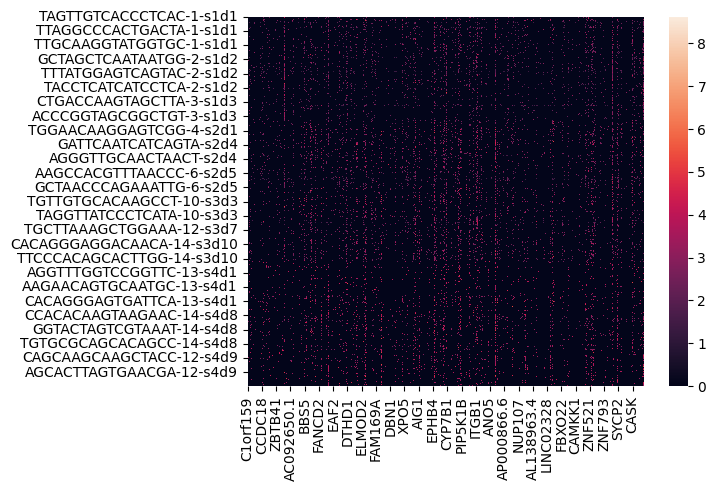

In [ ]:
sns.heatmap(train_data)

<Axes: >

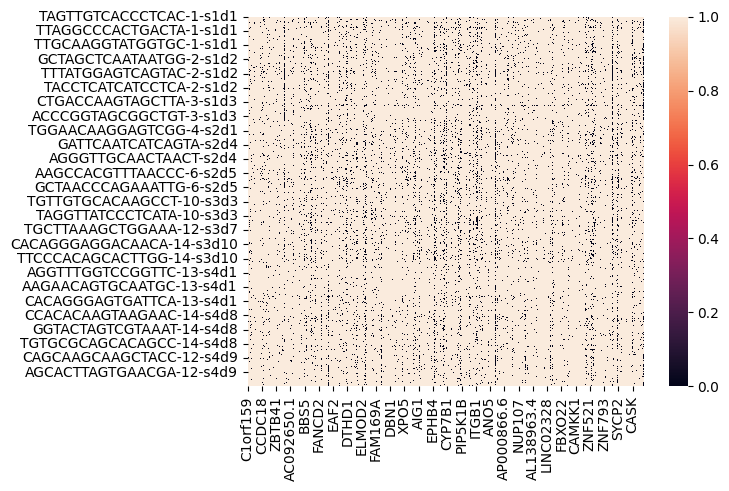

In [ ]:
sns.heatmap(train_data == 0)

# Scaling

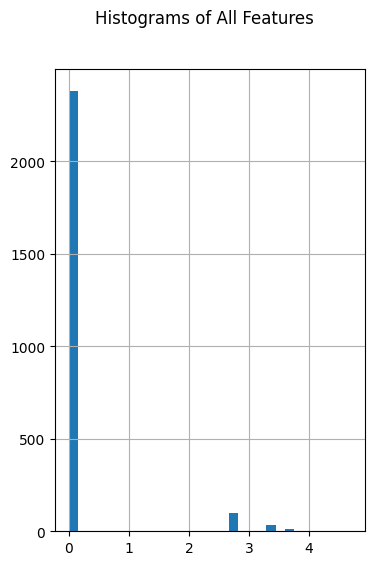

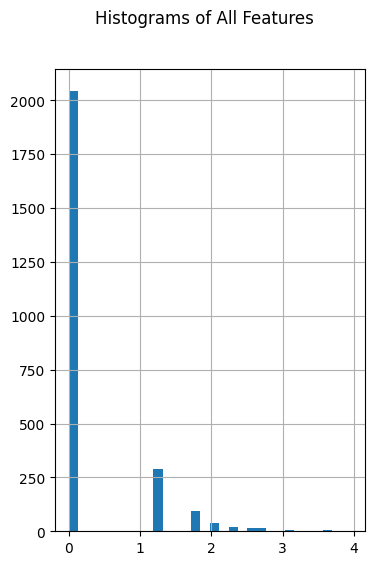

In [ ]:
# check data distribution
train_data.iloc[0].hist(bins=30, figsize=(4, 6))
plt.suptitle('Histograms of All Features')
plt.show()

test_data.iloc[0].hist(bins=30, figsize=(4, 6))
plt.suptitle('Histograms of All Features')
plt.show()

In [ ]:
# Scaling train data
from sklearn.preprocessing import StandardScaler # with normaly dist data
Ssc = StandardScaler()
# fitting ssc on train alone
Ssc_fit = Ssc.fit(train_data)
# transform both train and test
X_train_sc = Ssc_fit.transform(train_data)
X_test_sc = Ssc_fit.transform(test_data)

# Outlier removal

In [ ]:

IQR = train_data.quantile(0.75) - train_data.quantile(0.25)
sample_pct_hi_outlier = (train_data > train_data.quantile(0.75) + (1.5*IQR)).sum(axis=1) / train_data.shape[1]
sample_pct_hi_outlier

TAGTTGTCACCCTCAC-1-s1d1     0.049743
TTACCTGTCTATGACA-1-s1d1     0.037900
AATTTGCCATAATGAG-1-s1d1     0.040663
TGTCCTGGTCAATGTG-1-s1d1     0.042637
TGTATCGCAGCTCATA-1-s1d1     0.022503
                              ...   
TGTGGAGCAGAAATGC-12-s4d9    0.012238
GGTTTAATCTATGACA-12-s4d9    0.085669
ACTAATCCAGCAAGAT-12-s4d9    0.033952
CTATTCAGTTGTGATG-12-s4d9    0.034741
CACTTAAAGTCTGGGC-12-s4d9    0.031188
Length: 14339, dtype: float64

In [ ]:
IQR = train_data.quantile(0.75) - train_data.quantile(0.25)
sample_pct_lo_outlier = (train_data < train_data.quantile(0.25) - (1.5*IQR)).sum(axis=1) / train_data.shape[1]
sample_pct_lo_outlier

TAGTTGTCACCCTCAC-1-s1d1     0.0
TTACCTGTCTATGACA-1-s1d1     0.0
AATTTGCCATAATGAG-1-s1d1     0.0
TGTCCTGGTCAATGTG-1-s1d1     0.0
TGTATCGCAGCTCATA-1-s1d1     0.0
                           ... 
TGTGGAGCAGAAATGC-12-s4d9    0.0
GGTTTAATCTATGACA-12-s4d9    0.0
ACTAATCCAGCAAGAT-12-s4d9    0.0
CTATTCAGTTGTGATG-12-s4d9    0.0
CACTTAAAGTCTGGGC-12-s4d9    0.0
Length: 14339, dtype: float64

In [ ]:
# this code is just to let you know how to remove them based on threshold
# filtering samples with > 30% of its values outlier (it may be a contaminated sample)
DF_out = train_data.loc[(sample_pct_hi_outlier < 0.3) | (sample_pct_lo_outlier < 0.3),:]
DF_out.head()

,C1orf159,SLC35E2B,SLC2A5,GPR157,KIF1B,AL109811.2,DRAXIN,CLCN6,AL021155.5,KAZN,...,TMLHE,MT-ND1,MT-ND2,MT-ATP8,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,AL592183.1
TAGTTGTCACCCTCAC-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,2.676339,0.000000,3.334473,0.000000,3.334473,0.000000,0.000000,0.000000
TTACCTGTCTATGACA-1-s1d1,2.341237,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.341237,2.341237,0.000000,0.000000,0.000000,2.985084,0.000000,0.000000,0.000000
AATTTGCCATAATGAG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,2.205804,2.842295,0.000000,2.205804,3.228138,2.205804,0.000000
TGTCCTGGTCAATGTG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,2.607332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.607332
TGTATCGCAGCTCATA-1-s1d1,0.000000,2.966108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.000000,4.313009,2.966108,3.633166,4.029781,0.000000,0.000000


In [ ]:
DF_out

,C1orf159,SLC35E2B,SLC2A5,GPR157,KIF1B,AL109811.2,DRAXIN,CLCN6,AL021155.5,KAZN,...,TMLHE,MT-ND1,MT-ND2,MT-ATP8,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,AL592183.1
TAGTTGTCACCCTCAC-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,2.676339,0.000000,3.334473,0.000000,3.334473,0.000000,0.000000,0.000000
TTACCTGTCTATGACA-1-s1d1,2.341237,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,2.341237,2.341237,0.000000,0.000000,0.000000,2.985084,0.000000,0.000000,0.000000
AATTTGCCATAATGAG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,2.205804,2.842295,0.000000,2.205804,3.228138,2.205804,0.000000
TGTCCTGGTCAATGTG-1-s1d1,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,2.607332,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.607332
TGTATCGCAGCTCATA-1-s1d1,0.000000,2.966108,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,4.313009,2.966108,3.633166,4.029781,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGTGGAGCAGAAATGC-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,0.000000,3.951636,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
GGTTTAATCTATGACA-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,2.371941,0.0,0.0,2.371941,0.0,...,0.000000,3.903807,4.234501,3.406335,3.903807,3.685692,3.685692,4.234501,3.017315,0.000000
ACTAATCCAGCAAGAT-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.000000,4.072781,4.072781,0.000000,4.072781,4.472554,4.757377,4.472554,3.396521,0.000000
CTATTCAGTTGTGATG-12-s4d9,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,3.392346,0.0,...,3.392346,0.000000,0.000000,0.000000,4.068535,3.392346,3.392346,3.392346,0.000000,0.000000


In [ ]:
print(f"rows are reduced from {len(train_data)} to {len(DF_out)}")  #there is no change

rows are reduced from 14339 to 14339


# Feature selection

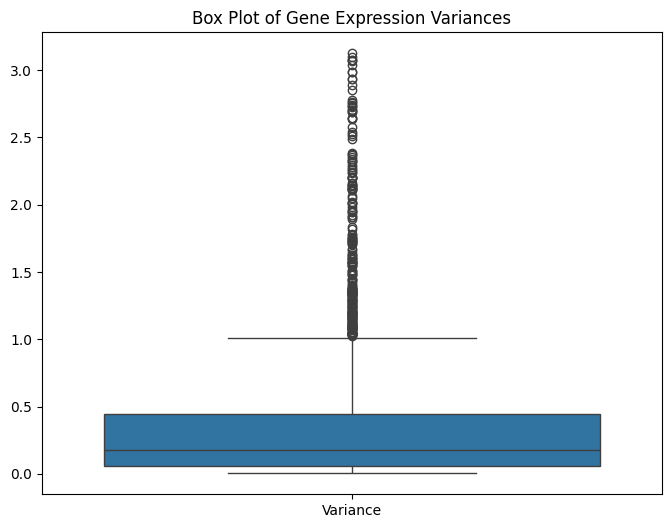

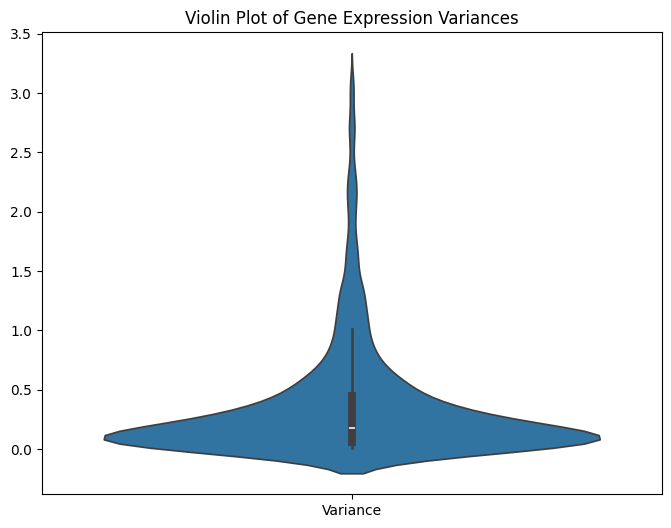

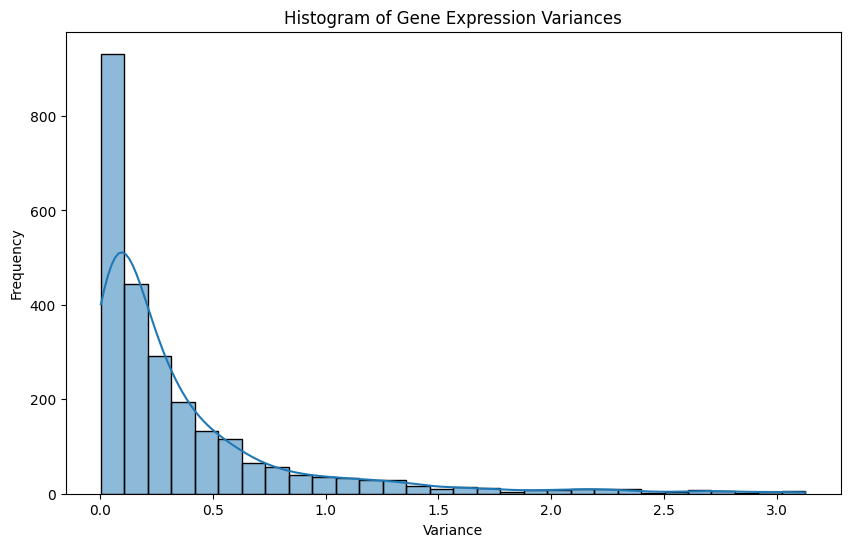

In [ ]:
# check data variance

# Calculate the variance of each gene
variances = train_data.var(axis=0)

# Sort variances for the bar plot
variances_sorted = variances.sort_values(ascending=False)


# Convert variances to a DataFrame for other plots
variance_df = pd.DataFrame(variances, columns=['Variance'])

# Box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=variance_df)
plt.title('Box Plot of Gene Expression Variances')
plt.show()

# Violin plot
plt.figure(figsize=(8, 6))
sns.violinplot(data=variance_df)
plt.title('Violin Plot of Gene Expression Variances')
plt.show()

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(variances, kde=True, bins=30)
plt.title('Histogram of Gene Expression Variances')
plt.xlabel('Variance')
plt.ylabel('Frequency')
plt.show()


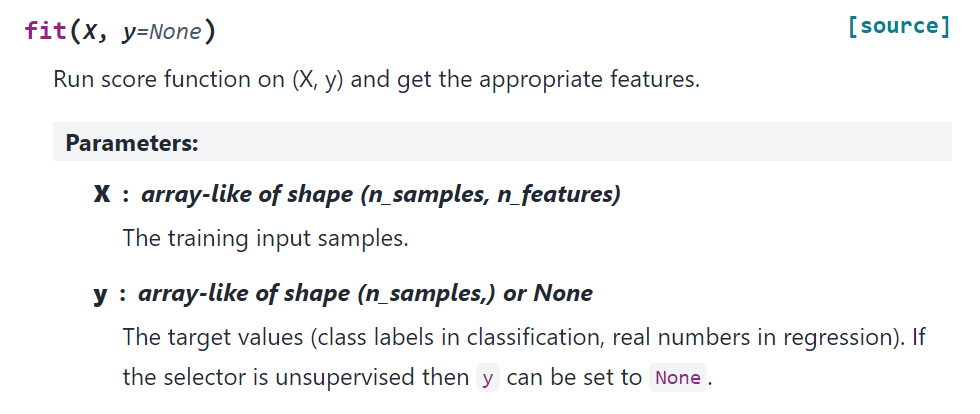

Univariate_selection

In [ ]:
# feature selection based on a univariate statistical test and selecting features based on a given significance level
from sklearn.feature_selection import SelectFpr

sfpr = SelectFpr(alpha=0.05)
sfpr_fit  = sfpr.fit(X_train_sc ,  y_train)
X_train_sc_filt = sfpr_fit.transform(X_train_sc)
X_test_sc_filt = sfpr_fit.transform(X_test_sc)


In [ ]:
print(f"columns are reduced from {X_train_sc.shape[1]} to {X_train_sc_filt.shape[1]}")

columns are reduced from 2533 to 1883


Multivariate_selection

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

In [ ]:
llog = LogisticRegression(C=0.01, penalty="l2")
SFL1 = SelectFromModel(llog)
SFL1_fit = SFL1.fit(X_train_sc_filt, y_train)

In [ ]:
X_train_ss_fs2 = SFL1_fit.transform(X_train_sc_filt)
X_test_ss_fs2 = SFL1_fit.transform(X_test_sc_filt)

In [ ]:
X_train_ss_fs2.shape

(14339, 703)

## Task 2: Dimensionality Reduction, Clustering

a) Apply 2 methods of dimensionality reduction one linear and other non-linear.  
b) Apply Clustering on the PCA components after chosing the appropriate n_components.  
c) Visualise your clusters and compare it to the actual cell_type.  
d) Apply appropriate metrics to decide best number of clusters and apply another metrics to compare your clustering to the actual label.  
N.B: You can find ideas about your unsupervised analysis from [here](https://satijalab.org/seurat/articles/pbmc3k_tutorial.html#assigning-cell-type-identity-to-clusters-1)

# linear dimensionality reduction

In [ ]:
# PCA
from sklearn.decomposition import PCA

In [ ]:
pca = PCA(n_components=1000)
X_pca = pca.fit_transform(X_train_sc_filt)

<Axes: >

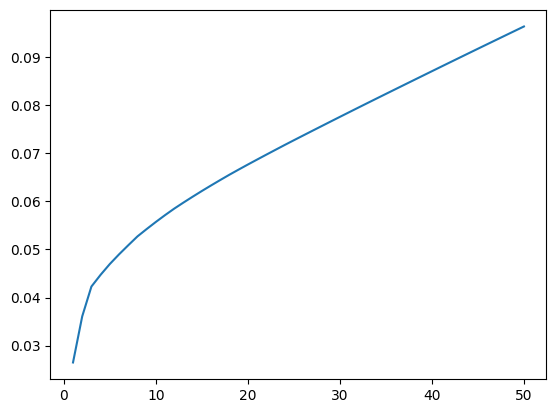

In [ ]:
n_PC = 50
cumsum_var_ratio = pca.explained_variance_ratio_.cumsum()
sns.lineplot(y=cumsum_var_ratio[:n_PC],x=[i for i in range(1,n_PC+1)])

<Axes: >

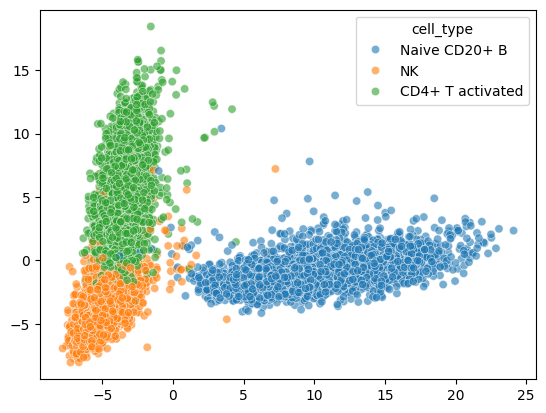

In [ ]:
sns.scatterplot(x= X_pca[:,0],y = X_pca[:,1],hue=metadata_train['cell_type'],alpha=0.6)

# non-linear dimensionality reduction

In [ ]:
#tsne

In [ ]:
from sklearn.manifold import TSNE

In [ ]:
# preplexity need to be tuned, till the best sepration observed
tsne = TSNE(init="pca", perplexity=30)
X_tsne = tsne.fit_transform(X_pca[:,:20])

<Axes: >

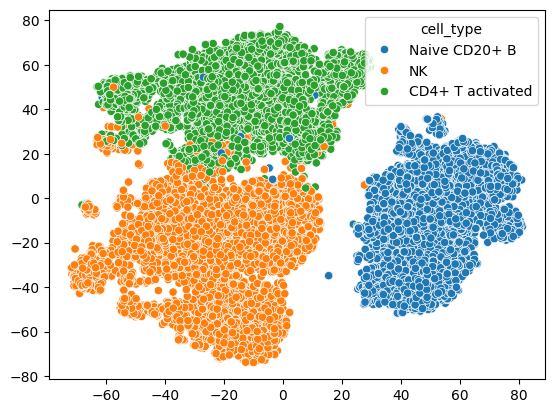

In [ ]:
sns.scatterplot(x= X_tsne[:,0],y= X_tsne[:,1],hue=metadata_train['cell_type'])

In [ ]:
# preplexity need to be tuned, till the best sepration observed
tsne = TSNE(init="pca",perplexity=50)
X_tsne = tsne.fit_transform(X_pca[:,:20])

<Axes: >

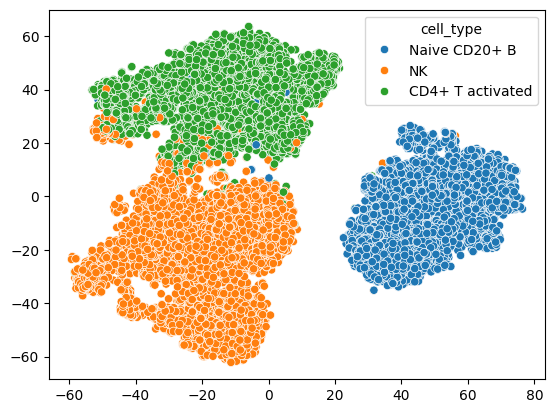

In [ ]:
sns.scatterplot(x= X_tsne[:,0],y= X_tsne[:,1],hue=metadata_train['cell_type'])

#umap

In [ ]:
# installing umap library
! pip install umap
! pip install umap-learn
import umap.umap_ as umap

  Preparing metadata (setup.py) ... done
  Created wheel for umap: filename=umap-0.1.1-py3-none-any.whl size=3543 sha256=7d509e3af65e084bfc38aa7e471aa5c8a13c7c8d5a7b0cd9a461cf37766ed825
  Stored in directory: /root/.cache/pip/wheels/15/f1/28/53dcf7a309118ed35d810a5f9cb995217800f3f269ab5771cb
Successfully built umap
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.6 MB/s eta 0:00:00


In [ ]:
um = umap.UMAP(n_neighbors=40)
X_umap = um.fit_transform(X_pca[:,:20])

<Axes: >

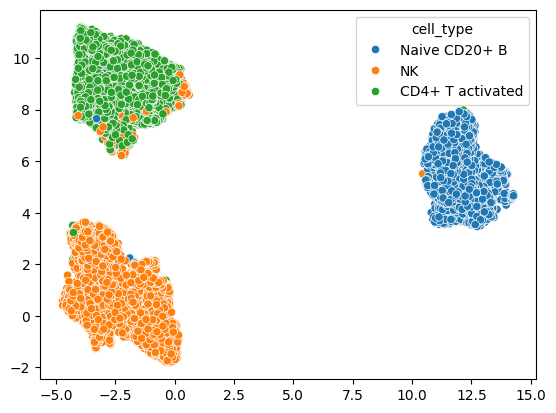

In [ ]:
sns.scatterplot(x= X_umap[:,0],y= X_umap[:,1],hue=metadata_train['cell_type'])

# Clustering

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [ ]:
kmeans = KMeans(n_clusters = 3)
km_label = kmeans.fit_predict(X_pca[:,:20])
###################
kmeans = KMeans(n_clusters = 3)
km = kmeans.fit(X_pca[:,:20])
km_label = km.predict(X_pca[:,:20])

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


<Axes: >

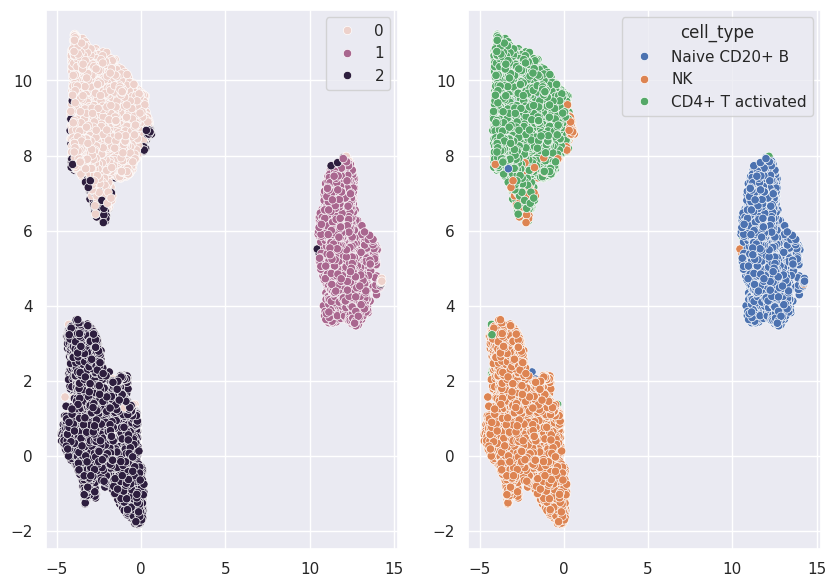

In [ ]:
sns.set(rc={'figure.figsize':(10,7)})
f, axes = plt.subplots(1, 2)
sns.scatterplot(x= X_umap[:,0],y= X_umap[:,1],hue=km_label, ax=axes[0])
sns.scatterplot(x= X_umap[:,0],y= X_umap[:,1],hue=metadata_train['cell_type'],ax=axes[1])

# Visualization

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

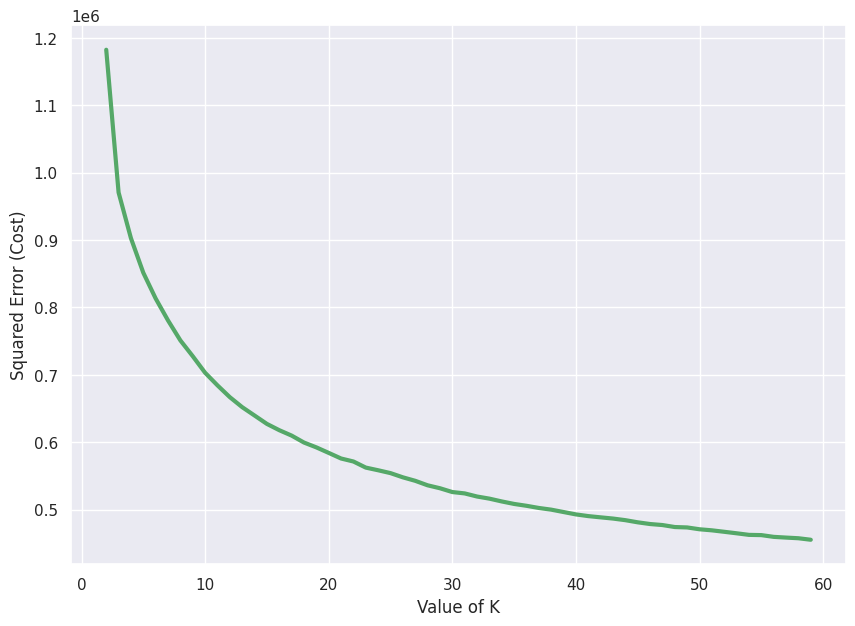

In [ ]:
cost =[]
sell = []
k_max = 60
for i in range(2, k_max):
    KM = KMeans(n_clusters = i, max_iter = 500)
    km_lab = KM.fit_predict(X_pca[:,:20])

    # calculates squared error
    # for the clustered points
    cost.append(KM.inertia_)
    sell.append(silhouette_score(X_pca[:,:20],pd.Categorical(km_lab)))

# plot the cost against K values
plt.plot(range(2, k_max), cost, color ='g', linewidth ='3')
plt.xlabel("Value of K")
plt.ylabel("Squared Error (Cost)")
plt.show() # clear the plot

# the point of the elbow is the
# most optimal value for choosing k

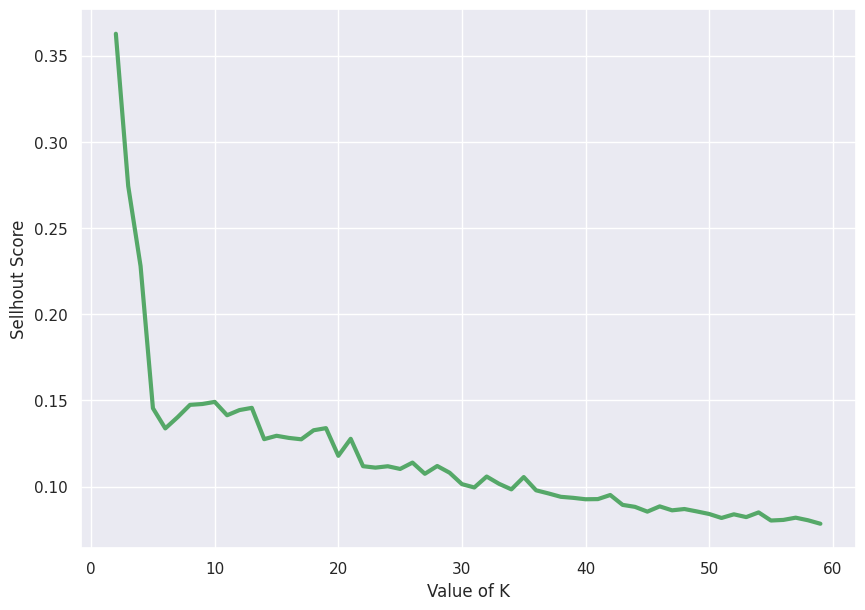

In [ ]:
# plot the sellhoute against K values
plt.plot(range(2, k_max), sell, color ='g', linewidth ='3')
plt.xlabel("Value of K")
plt.ylabel("Sellhout Score")
plt.show() # clear the plot

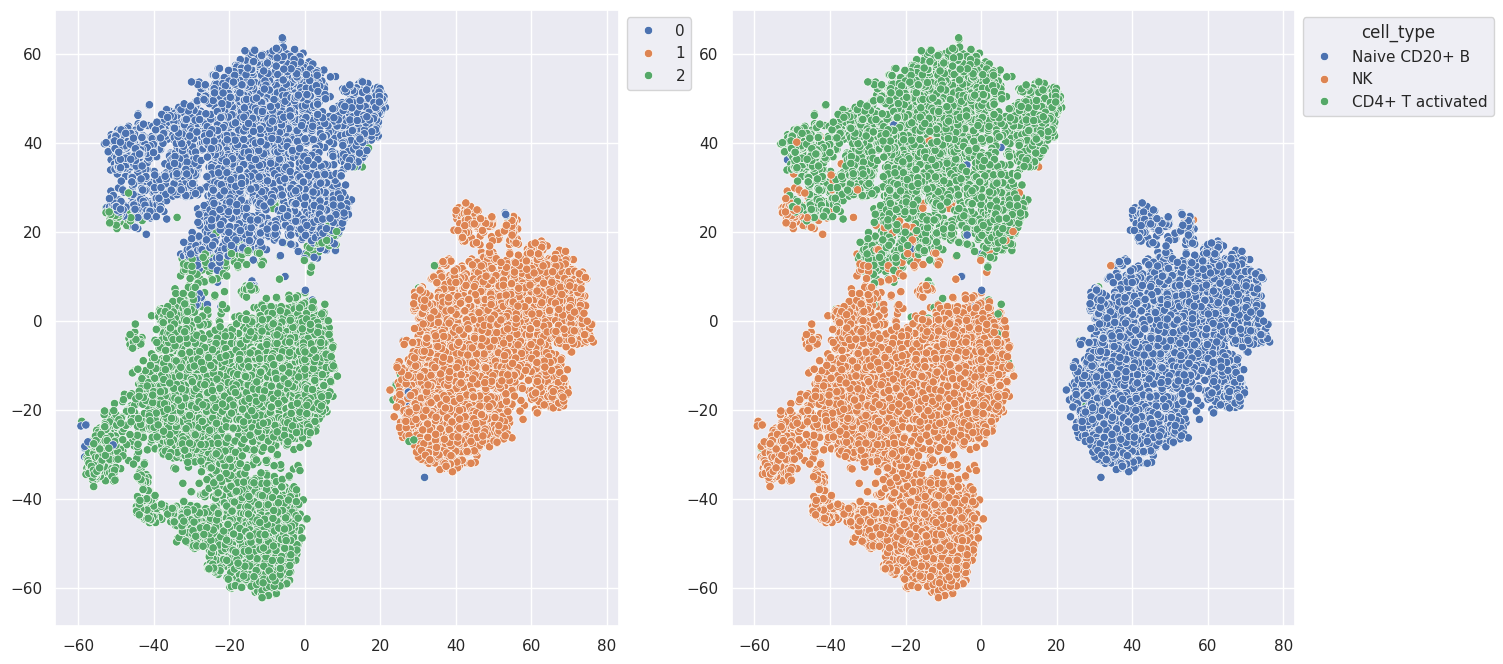

In [ ]:
plt.rcParams['figure.figsize'] = (16,8)
f, axes = plt.subplots(1, 2)
sns.scatterplot(x= X_tsne[:,0],y= X_tsne[:,1],hue= pd.Categorical(km_label), ax=axes[0])
sns.scatterplot(x= X_tsne[:,0],y= X_tsne[:,1],hue=metadata_train['cell_type'],ax=axes[1])
sns.move_legend(axes[0], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(axes[1], "upper left", bbox_to_anchor=(1, 1))


Our target variable is categorical data(cell types) therefore we will used supervised classification models

## Task 3: Classifier and Quality Measure Selection

a) Select at least two classifiers to solve the classification task at hand. Motivate the choice of your classifiers (e.g. complexity, performance, interpretability).


b) Select at least two quality measures to evaluate model performance and justify your choice.



In [ ]:
from sklearn.ensemble import RandomForestClassifier  #for complexity because of multiple trees

In [ ]:
#RandomForest
RF = RandomForestClassifier(n_estimators=200, max_depth = None)
RF_fit = RF.fit(X_train_sc_filt, y_train )
y_test_pred = RF_fit.predict(X_test_sc_filt)
y_test_pred

array(['CD4+ T activated', 'Naive CD20+ B', 'NK', ..., 'CD4+ T activated',
       'NK', 'Naive CD20+ B'], dtype=object)

In [ ]:
import pandas as pd

X_test_sc_filt_df = pd.DataFrame(X_test_sc_filt)
print(RF_fit.predict(X_test_sc_filt_df.iloc[[1], :]))
print(y_test[1])

['Naive CD20+ B']
Naive CD20+ B


In [ ]:
# KNN model
from sklearn.neighbors import KNeighborsClassifier
KNN_raw = KNeighborsClassifier(n_neighbors=5)
KNN_raw_fit = KNN_raw.fit(X_train_sc_filt,y_train )
print(KNN_raw_fit.predict(X_test_sc_filt_df.iloc[[1], :]))
print(y_test[1])
acc_raw = KNN_raw_fit.score(X_test_sc_filt,y_test)
print(f"Accuracy of model trained on raw is {round(acc_raw,3)}")

['NK']
Naive CD20+ B
Accuracy of model trained on raw is 0.53


In [ ]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=200)
lg_fit=model.fit(X_train_sc_filt, y_train)
y_pred = model.predict(X_test_sc_filt)
lg_score = lg_fit.score(X_test_sc_filt,y_test)
print(round(lg_score,3))

0.985


**Evaluation**

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_true=y_test, y_pred=y_test_pred))
#We'll use accuracy and f1_score to evaluate the model

                  precision    recall  f1-score   support

CD4+ T activated       0.98      0.97      0.98       993
              NK       0.98      0.99      0.98      1254
   Naive CD20+ B       1.00      1.00      1.00       921

        accuracy                           0.98      3168
       macro avg       0.99      0.98      0.99      3168
    weighted avg       0.98      0.98      0.98      3168



## Task 4: Parameter Tuning and Validation

a) Carefully choose the set of parameters of the selected classifiers.

b) Decide for a validation strategy (e.g. Hold-out, Cross Validation), carefully select the ratios between training and validation or number of folds and justify your decision.

c) Use the validation strategy to evaluate the chosen range of parameters. Create a plot depicting the relation between parameter range and quality measures. Use the plot to find the optimal set of parameters for each method. Discuss what the best parameters are and how these were chosen.


In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.feature_selection import SelectFromModel

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([
    ("sscaler", StandardScaler()),
    ("MFS", SelectFromModel(estimator=LogisticRegression( penalty="l1",solver="liblinear")) ),
    ("RF", RandomForestClassifier())
])

parameters = {
    'RF__n_estimators': [100, 500],
    'RF__min_samples_leaf': [1, 5],
    "MFS__estimator__C":[0.1, 0.01]
}

GSCV = GridSearchCV(pipe, parameters, scoring="f1_macro", cv=5, return_train_score=True, verbose=3)
GSCV_fit = GSCV.fit(train_data, y_train)


Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV 1/5] END MFS__estimator__C=0.1, RF__min_samples_leaf=1, RF__n_estimators=100;, score=(train=1.000, test=0.979) total time=  22.2s
[CV 2/5] END MFS__estimator__C=0.1, RF__min_samples_leaf=1, RF__n_estimators=100;, score=(train=1.000, test=0.971) total time=  20.7s
[CV 3/5] END MFS__estimator__C=0.1, RF__min_samples_leaf=1, RF__n_estimators=100;, score=(train=1.000, test=0.986) total time=  21.0s
[CV 4/5] END MFS__estimator__C=0.1, RF__min_samples_leaf=1, RF__n_estimators=100;, score=(train=1.000, test=0.979) total time=  20.1s
[CV 5/5] END MFS__estimator__C=0.1, RF__min_samples_leaf=1, RF__n_estimators=100;, score=(train=1.000, test=0.980) total time=  22.1s
[CV 1/5] END MFS__estimator__C=0.1, RF__min_samples_leaf=1, RF__n_estimators=500;, score=(train=1.000, test=0.979) total time=  50.8s
[CV 2/5] END MFS__estimator__C=0.1, RF__min_samples_leaf=1, RF__n_estimators=500;, score=(train=1.000, test=0.971) total time=  54.0s
[C

# Task 5: Model Training

a) Select one classifier/ model that is most generalizable and will perform best on the external test set.

b) With chosen classifiers and optimal parameters, train your model with data (training data).


In [ ]:
best_model = GSCV_fit.best_estimator_
print("Best Model:\n", best_model)

Best Model:
 Pipeline(steps=[('sscaler', StandardScaler()),
                ('MFS',
                 SelectFromModel(estimator=LogisticRegression(C=0.1,
                                                              penalty='l1',
                                                              solver='liblinear'))),
                ('RF', RandomForestClassifier(n_estimators=500))])


In [ ]:
# Access the best parameters
best_params = GSCV_fit.best_params_
print("Best Parameters:\n", best_params)

Best Parameters:
 {'MFS__estimator__C': 0.1, 'RF__min_samples_leaf': 1, 'RF__n_estimators': 500}


In [ ]:
best_model.fit(train_data, y_train)

Pipeline(steps=[('sscaler', StandardScaler()),
                ('MFS',
                 SelectFromModel(estimator=LogisticRegression(C=0.1,
                                                              penalty='l1',
                                                              solver='liblinear'))),
                ('RF', RandomForestClassifier(n_estimators=500))])

In [ ]:
y_test_pred = GSCV_fit.best_estimator_.predict(test_data)
print(classification_report(y_test,y_test_pred) )

                  precision    recall  f1-score   support

CD4+ T activated       0.99      0.97      0.98       993
              NK       0.98      0.99      0.98      1254
   Naive CD20+ B       1.00      1.00      1.00       921

        accuracy                           0.99      3168
       macro avg       0.99      0.99      0.99      3168
    weighted avg       0.99      0.99      0.99      3168



## Task 6: Model interpretation and feature importance

a) Depending on your choice of model, select an adequate feature importance method (e.g. Linear weights, information gain, forward/backward selection) and explain your decision.

b) Identify the 10 most informative features for your model and visualize them in a bar plot sorted by their importance.

c) choose 4 cells and make local interpretability of their predicition and explain the biological meaning of the important genes by searching top features in [ensemble data base](https://www.ensembl.org/index.html)

#using both linear weights and information gain because they give more interpretability

In [ ]:
#for logistic Regression
f_i = [int(i[1:]) for i in sfpr.get_feature_names_out()]
f_n = train_data.columns[f_i]

In [ ]:
LR = LogisticRegression(penalty="l1",C=0.1, solver='liblinear')
LR_fit = LR.fit(X_train_sc_filt, y_train )
y_test_pred = LR_fit.predict(X_test_sc_filt)
print(classification_report(y_test,y_test_pred))

                  precision    recall  f1-score   support

CD4+ T activated       0.99      0.98      0.98       993
              NK       0.98      0.99      0.98      1254
   Naive CD20+ B       1.00      1.00      1.00       921

        accuracy                           0.99      3168
       macro avg       0.99      0.99      0.99      3168
    weighted avg       0.99      0.99      0.99      3168



<Axes: xlabel='None'>

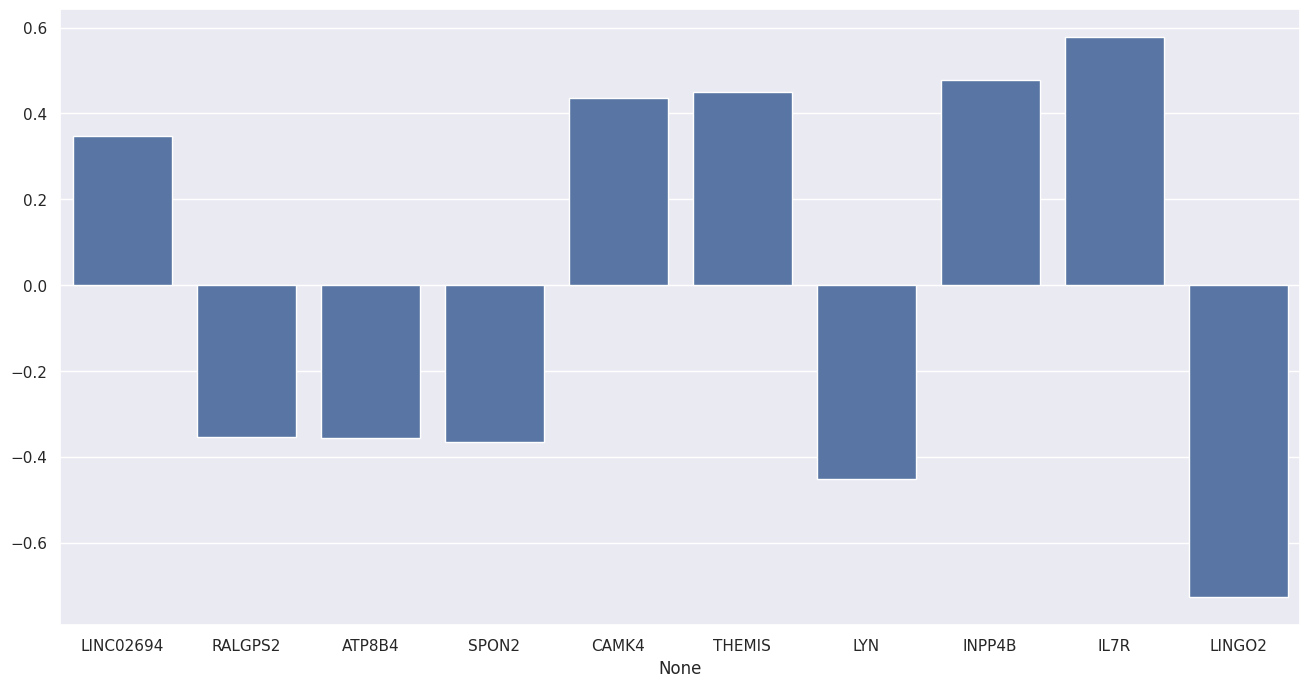

In [ ]:
sort_i = np.argsort(np.abs(LR_fit.coef_[0])) #coef_ is an attribute of the fitted model that contains the coefficients (weights) assigned to each feature.
sns.barplot(x = f_n[sort_i][-10:],y=LR_fit.coef_[0][sort_i][-10:])

In [ ]:
#for tree-based models
f_i = [int(i[1:]) for i in GSCV_fit.best_estimator_.named_steps["MFS"].get_feature_names_out()]
f_n = GSCV_fit.best_estimator_.feature_names_in_[f_i]

<Axes: >

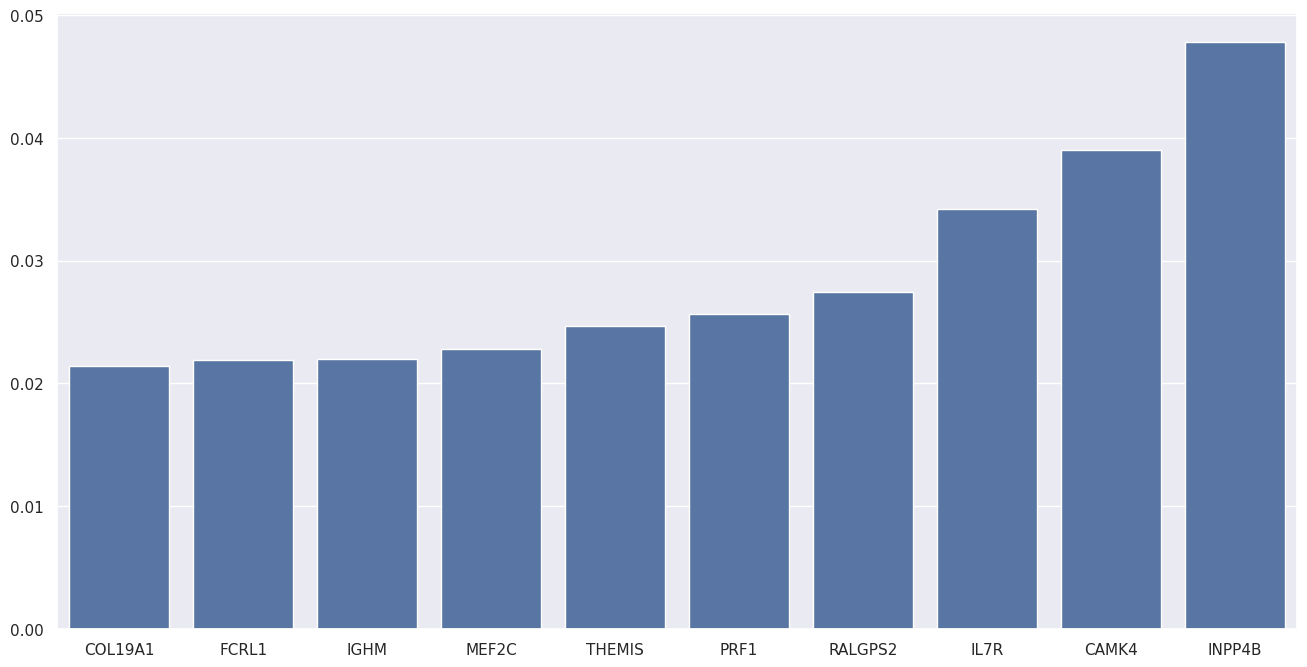

In [ ]:
# Assuming 'feature_importances_' is from the same model used to generate 'sort_i'
import seaborn as sns
sort_i_adj = np.argsort(GSCV_fit.best_estimator_.named_steps["RF"].feature_importances_)
# Use the adjusted sort indices to select the top 10 features
sns.barplot(x=f_n[sort_i_adj][-10:], y=GSCV_fit.best_estimator_.named_steps["RF"].feature_importances_[sort_i_adj][-10:])


# **ELI5**

In [ ]:
! pip install eli5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for eli5: filename=eli5-0.13.0-py2.py3-none-any.whl size=107720 sha256=c01695236085336c7b4db1bfa0e1f7e11d417e24cf4e1f369235fc8a6ee859e6
  Stored in directory: /root/.cache/pip/wheels/b8/58/ef/2cf4c306898c2338d51540e0922c8e0d6028e07007085c0004
Successfully built eli5


In [ ]:
import eli5
from eli5.sklearn import PermutationImportance

In [ ]:
eli5.show_weights(GSCV_fit.best_estimator_,feature_names=GSCV_fit.best_estimator_.feature_names_in_)

Weight,Feature
0.0478 ± 0.1287,INPP4B
0.0390 ± 0.1108,CAMK4
0.0342 ± 0.1036,IL7R
0.0275 ± 0.1208,RALGPS2
0.0257 ± 0.0860,PRF1
0.0247 ± 0.0817,THEMIS
0.0228 ± 0.1083,MEF2C
0.0220 ± 0.0983,IGHM
0.0219 ± 0.1071,FCRL1
0.0214 ± 0.1037,COL19A1


# **LOCAL INTERPRETABILITY**

# Lime

In [ ]:
! pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283835 sha256=47c47f290569530ed9b175139ef4fe0ecf10fc3a3a9df72a896173af1836d35d
  Stored in directory: /root/.cache/pip/wheels/fd/a2/af/9ac0a1a85a27f314a06b39e1f492bee1547d52549a4606ed89
Successfully built lime


In [ ]:
import lime
import lime.lime_tabular

In [ ]:
feature_names_out = GSCV_fit.best_estimator_.named_steps["MFS"].get_feature_names_out()
print("Feature names out:", feature_names_out)

Feature names out: ['x5' 'x8' 'x11' 'x12' 'x15' 'x16' 'x18' 'x31' 'x32' 'x37' 'x38' 'x41'
 'x42' 'x43' 'x44' 'x52' 'x54' 'x63' 'x64' 'x66' 'x69' 'x71' 'x72' 'x73'
 'x74' 'x80' 'x87' 'x89' 'x92' 'x96' 'x100' 'x101' 'x106' 'x111' 'x112'
 'x113' 'x115' 'x119' 'x120' 'x125' 'x131' 'x137' 'x138' 'x139' 'x141'
 'x143' 'x147' 'x148' 'x150' 'x155' 'x159' 'x161' 'x168' 'x174' 'x175'
 'x179' 'x180' 'x181' 'x183' 'x185' 'x187' 'x188' 'x189' 'x191' 'x193'
 'x198' 'x212' 'x215' 'x216' 'x219' 'x223' 'x226' 'x227' 'x228' 'x233'
 'x234' 'x235' 'x238' 'x239' 'x240' 'x241' 'x246' 'x247' 'x249' 'x252'
 'x259' 'x261' 'x262' 'x265' 'x270' 'x271' 'x274' 'x277' 'x284' 'x287'
 'x288' 'x294' 'x302' 'x306' 'x307' 'x309' 'x311' 'x312' 'x315' 'x316'
 'x319' 'x327' 'x331' 'x332' 'x335' 'x336' 'x339' 'x343' 'x347' 'x355'
 'x357' 'x361' 'x362' 'x363' 'x367' 'x370' 'x374' 'x377' 'x379' 'x380'
 'x381' 'x387' 'x389' 'x391' 'x393' 'x400' 'x403' 'x406' 'x409' 'x410'
 'x411' 'x413' 'x414' 'x415' 'x423' 'x425' 'x434' 'x438

In [ ]:
explainer = lime.lime_tabular.LimeTabularExplainer(X_train_sc_filt, feature_names=f_n, class_names=["CD4+ T activated", "NK", "Naive CD20+ B"], discretize_continuous=True)

In [ ]:
i = 0
exp = explainer.explain_instance(X_test_sc_filt[i], RF_fit.predict_proba, num_features=10, top_labels=3)

In [ ]:
exp.show_in_notebook(show_table=True, show_all=False)